In [1]:
# Check GPU

import torch

print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

PyTorch Version: 2.11.0+cu128
GPU Available: True
GPU Name: Tesla T4
Using Device: cuda


In [2]:
# ==============================
# Import Required Libraries
# ==============================

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# ==============================
# Load CIFAR-10 Dataset
# ==============================

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

classes = train_dataset.classes

print("Training Images :", len(train_dataset))
print("Testing Images  :", len(test_dataset))
print("Classes         :", classes)

100%|██████████| 170M/170M [42:19<00:00, 67.1kB/s]


Training Images : 50000
Testing Images  : 10000
Classes         : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [5]:
# ===========================================
# Custom Residual Block
# ===========================================

class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        # Skip connection
        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:

            self.shortcut = nn.Sequential(

                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm2d(out_channels)

            )

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity

        out = self.relu(out)

        return out


print("Residual Block Created Successfully!")

Residual Block Created Successfully!


In [6]:
# ===========================================
# Custom ResNet
# ===========================================

class CustomResNet(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.initial = nn.Sequential(

            nn.Conv2d(
                3,
                64,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(inplace=True)

        )

        # Residual Stage 1
        self.stage1 = nn.Sequential(

            ResidualBlock(64,64),
            ResidualBlock(64,64)

        )

        # Residual Stage 2
        self.stage2 = nn.Sequential(

            ResidualBlock(64,128,stride=2),
            ResidualBlock(128,128)

        )

        # Residual Stage 3
        self.stage3 = nn.Sequential(

            ResidualBlock(128,256,stride=2),
            ResidualBlock(256,256)

        )

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))

        self.fc = nn.Linear(256,num_classes)

    def forward(self,x):

        x = self.initial(x)

        x = self.stage1(x)

        x = self.stage2(x)

        x = self.stage3(x)

        x = self.avgpool(x)

        x = torch.flatten(x,1)

        x = self.fc(x)

        return x


print("Custom ResNet Created Successfully!")

Custom ResNet Created Successfully!


In [7]:
# ===========================================
# Test the Model
# ===========================================

model = CustomResNet().to(device)

dummy = torch.randn(4,3,32,32).to(device)

output = model(dummy)

print("Output Shape :", output.shape)
print(model)

Output Shape : torch.Size([4, 10])
CustomResNet(
  (initial): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (stage1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(

In [8]:
# ===========================================
# Loss Function and Optimizer
# ===========================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 10

train_losses = []
train_accuracies = []

print("Training setup completed!")

Training setup completed!


In [9]:
# ===========================================
# Training Loop
# ===========================================

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_acc:.2f}%"
    )

print("Training Finished!")

Epoch [1/10] Loss: 1.3904 Accuracy: 48.60%
Epoch [2/10] Loss: 0.9316 Accuracy: 66.85%
Epoch [3/10] Loss: 0.7364 Accuracy: 74.11%
Epoch [4/10] Loss: 0.6191 Accuracy: 78.56%
Epoch [5/10] Loss: 0.5367 Accuracy: 81.17%
Epoch [6/10] Loss: 0.4784 Accuracy: 83.55%
Epoch [7/10] Loss: 0.4310 Accuracy: 85.12%
Epoch [8/10] Loss: 0.3985 Accuracy: 86.15%
Epoch [9/10] Loss: 0.3582 Accuracy: 87.68%
Epoch [10/10] Loss: 0.3363 Accuracy: 88.37%
Training Finished!


In [10]:
# ===========================================
# Evaluate on Test Set
# ===========================================

model.eval()

correct = 0
total = 0

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

test_accuracy = 100 * correct / total

print(f"Test Accuracy : {test_accuracy:.2f}%")

Test Accuracy : 84.34%


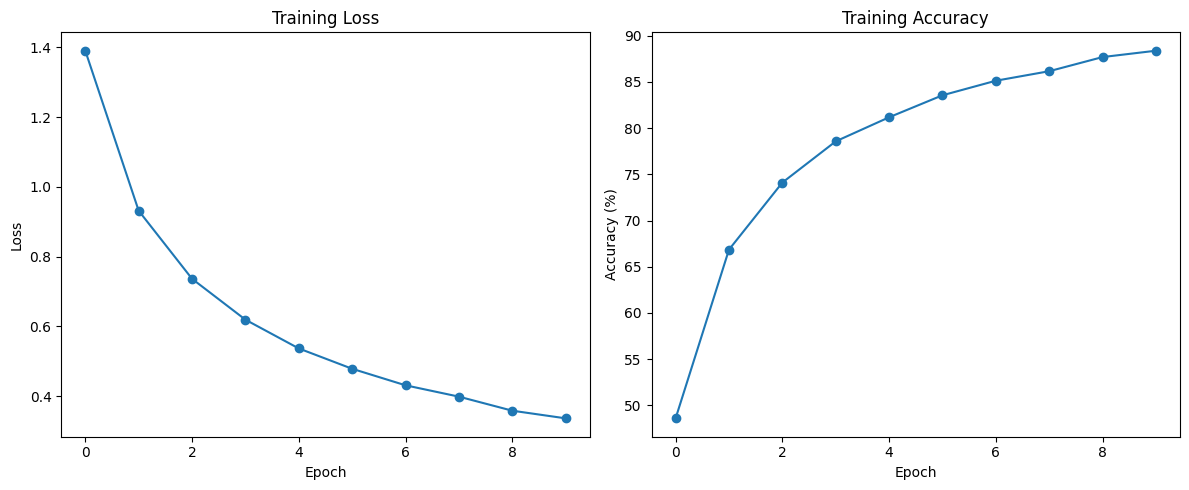

In [11]:
# ===========================================
# Training Curves
# ===========================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(train_accuracies, marker='o')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

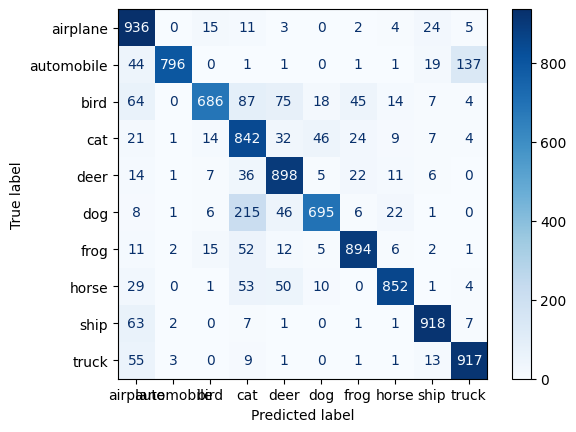

In [12]:
# ===========================================
# Confusion Matrix
# ===========================================

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

plt.figure(figsize=(10,10))
disp.plot(cmap="Blues")
plt.show()

In [13]:
# ===========================================
# Classification Report
# ===========================================

print(classification_report(
    all_labels,
    all_predictions,
    target_names=classes
))

              precision    recall  f1-score   support

    airplane       0.75      0.94      0.83      1000
  automobile       0.99      0.80      0.88      1000
        bird       0.92      0.69      0.79      1000
         cat       0.64      0.84      0.73      1000
        deer       0.80      0.90      0.85      1000
         dog       0.89      0.69      0.78      1000
        frog       0.90      0.89      0.90      1000
       horse       0.93      0.85      0.89      1000
        ship       0.92      0.92      0.92      1000
       truck       0.85      0.92      0.88      1000

    accuracy                           0.84     10000
   macro avg       0.86      0.84      0.84     10000
weighted avg       0.86      0.84      0.84     10000



In [14]:
# ===========================================
# Save Model
# ===========================================

torch.save(
    model.state_dict(),
    "custom_resnet_cifar10.pth"
)

print("Model Saved Successfully!")

Model Saved Successfully!
